# Xenium Pancreas Download and Cluster

In [2]:
import os
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import spatialdata as sd

import celldega as dega

from spatialdata_io import xenium

# Download the Xenium Daset from 10X

In [4]:
# Define paths
output_dir = "data/xenium-pancreas"
zip_filename = "Xenium_V1_human_Pancreas_FFPE_outs.zip"
zip_path = os.path.join(output_dir, zip_filename)
unzip_dir = os.path.join(output_dir, "Xenium_V1_human_Pancreas_FFPE_outs")
url = "https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Pancreas_FFPE/Xenium_V1_human_Pancreas_FFPE_outs.zip"

# Ensure base directory exists
os.makedirs(output_dir, exist_ok=True)

# Download if needed
if not os.path.exists(zip_path):
    print("Downloading with curl...")
    subprocess.run([
        "curl", "-L", url, "-o", zip_path
    ], check=True)
else:
    print("Zip file already exists. Skipping download.")

# Unzip if needed
if not os.path.exists(unzip_dir):
    print("Unzipping into its own folder...")
    os.makedirs(unzip_dir, exist_ok=True)
    subprocess.run(["unzip", "-o", zip_path, "-d", unzip_dir], check=True)
else:
    print("Already unzipped. Skipping extraction.")


Zip file already exists. Skipping download.
Already unzipped. Skipping extraction.


In [4]:
sdata = xenium(unzip_dir)
sdata

INFO     reading data/xenium-pancreas/Xenium_V1_human_Pancreas_FFPE_outs/cell_feature_matrix.h5                    


/var/folders/8d/jxpy9rd10j7fp2rcj_s5sz3c0000gq/T/ipykernel_28061/4097300947.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(unzip_dir)


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (5, 13770, 34155), (5, 6885, 17077), (5, 3442, 8538), (5, 1721, 4269), (5, 860, 2134)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (13770, 34155), (6885, 17077), (3442, 8538), (1721, 4269), (860, 2134)
│     └── 'nucleus_labels': DataTree[yx] (13770, 34155), (6885, 17077), (3442, 8538), (1721, 4269), (860, 2134)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (140702, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (140702, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (136531, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (140702, 377)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [5]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 140702 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

### Calculate QC Metrics

In [6]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [7]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.006005935170375317
Negative decoding count % : 0.0014334407204219034


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

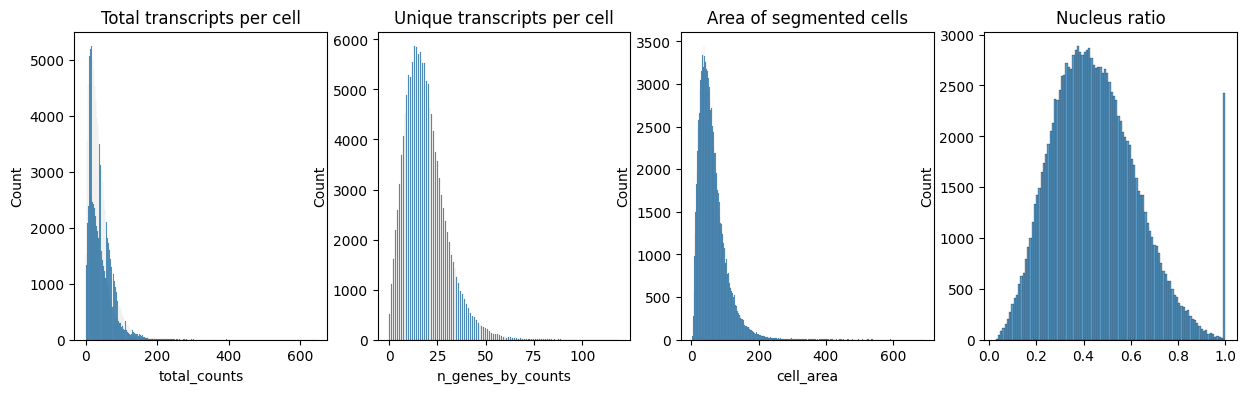

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

In [9]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [10]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

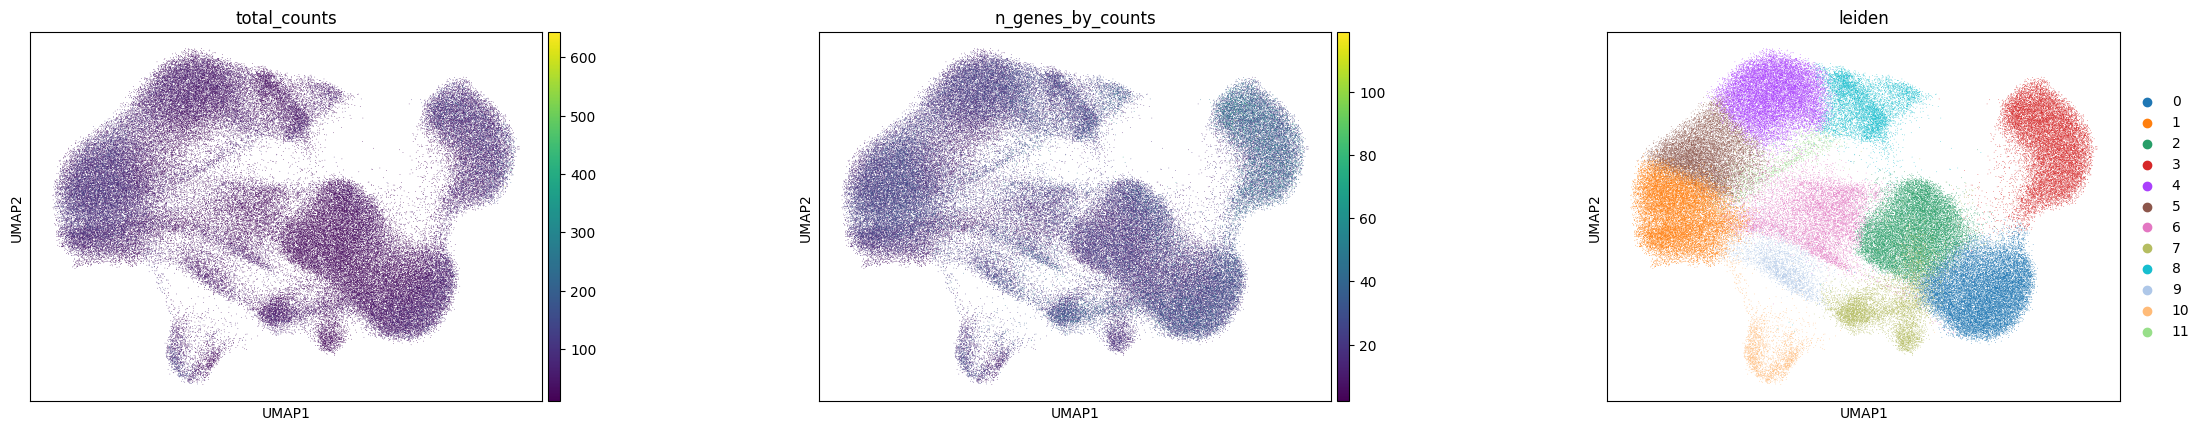

In [11]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


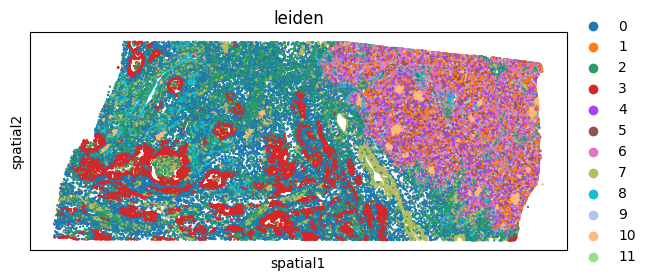

In [12]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

In [ ]:
adata.write_h5ad(os.path.join(output_dir, 'Xenium_V1_human_Pancreas_FFPE_outs.h5ad'))

In [3]:
base_url = 'https://raw.githubusercontent.com/broadinstitute/celldega_Xenium_human_Pancreas_FFPE/main/Landscape_Xenium_V1_human_Pancreas_FFPE_outs_webp'
landscape = dega.viz.Landscape(
    technology='Xenium', 
    height=600,
    base_url = base_url,
    adata=adata,
    cell_attr=['leiden']
)

landscape